# Notebook 11 – Unsupervised Learning
Using `data.csv` (retail orders)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [7]:
df = pd.read_csv('data.csv', encoding='latin1')
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
customers = df.groupby('CustomerID').agg(
    Spend=('TotalPrice', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index().sample(n=300, random_state=1)
customers.head()

,CustomerID,Spend,Quantity
3092,16565.0,173.70,46
3207,16725.0,781.02,294
2742,16091.0,315.06,154
1030,13739.0,216.90,54
2830,16202.0,365.27,191


## 1. What is Unsupervised Learning?
**What:** Learning from data that has no labels — the model finds patterns on its own.

**Example:** Our `customers` table has no "customer type" column — just numbers.
    
**Why:** Most real data has no labels attached; we still want insights from it.


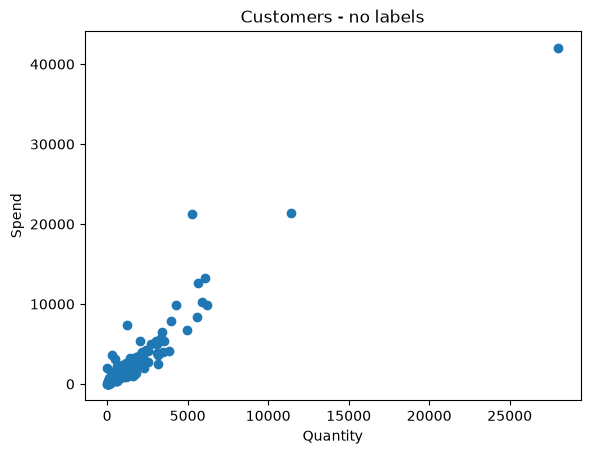

In [3]:
plt.scatter(customers['Quantity'], customers['Spend'])
plt.xlabel('Quantity')
plt.ylabel('Spend')
plt.title('Customers - no labels')
plt.show()

## 2. Supervised vs Unsupervised Learning
**What:** Supervised = we know the correct answers. Unsupervised = we don't.
    
**Example:** Notebook 10 (SVM) knew "High/Low Value" labels. Here, we don't label customers at all.
    
**Why:** Tells us which approach to use, depending on whether labels exist.

| | Supervised | Unsupervised |
|---|---|---|
| Labels | Yes | No |
| Goal | Predict a known answer | Find hidden groups/patterns |

**When labels are unavailable:** Labeling can be slow, costly, or the categories may not even be known yet (e.g., no one has manually tagged customer types). This is exactly when unsupervised learning is used.


## 3. Clustering
**What:** Automatically grouping similar data points together.

**Example:** Group customers into 3 clusters by `Quantity` and `Spend`.

**Why:** Helps a business understand different customer types without manual labeling.


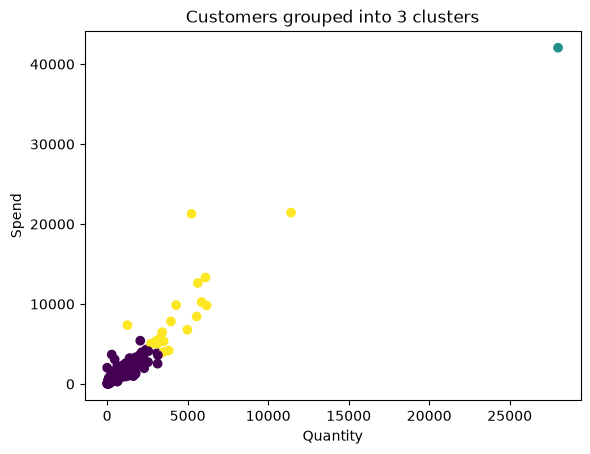

In [8]:
X = StandardScaler().fit_transform(customers[['Quantity', 'Spend']])
customers['Cluster'] = KMeans(n_clusters=3, random_state=1, n_init=10).fit_predict(X)
plt.scatter(customers['Quantity'], customers['Spend'], c=customers['Cluster'], cmap='viridis')
plt.xlabel('Quantity')
plt.ylabel('Spend')
plt.title('Customers grouped into 3 clusters')
plt.show()

## 4. Dimensionality Reduction
**What:** Compressing many features into fewer, while keeping the important info.

**Example:** Squeeze 3 customer features down to 2, so we can still plot them.

**Why:** Easier to visualize, faster to process, removes noise.


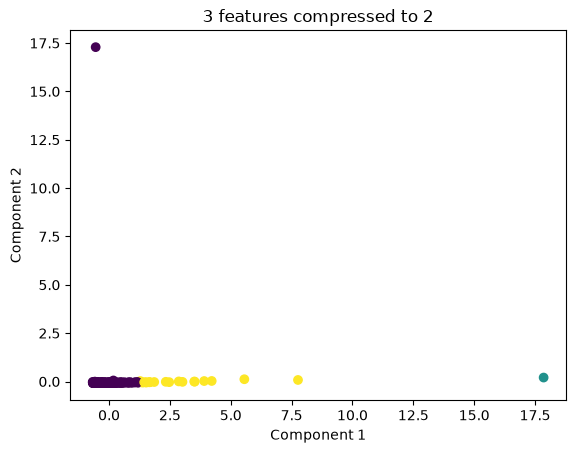

In [5]:
customers['AvgOrder'] = customers['Spend'] / customers['Quantity']
X3 = StandardScaler().fit_transform(customers[['Quantity', 'Spend', 'AvgOrder']])
X_pca = PCA(n_components=2).fit_transform(X3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customers['Cluster'], cmap='viridis')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('3 features compressed to 2')
plt.show()

## 5. Applications
**What:** Real situations where unsupervised learning is used.

**Examples:** Customer segmentation, market basket analysis, anomaly detection, recommendations, data compression.
    
**Why:** These all work without needing labeled data.


In [6]:
limit = df['TotalPrice'].mean() + 3 * df['TotalPrice'].std()
outliers = df[df['TotalPrice'] > limit]
print("Unusual orders found:", len(outliers))

Unusual orders found: 535
